# Medical Image Classification - Preprocessing Pipeline

**Purpose:** Design and implement preprocessing strategies for chest X-ray images.

**Key Goals:**
1. Resize images to consistent dimensions
2. Apply contrast enhancement (CLAHE)
3. Design appropriate data augmentation strategy
4. Create PyTorch datasets and dataloaders
5. Visualize preprocessing effects
6. Prepare for model training

## 1. Setup & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import json

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [3]:
train_df = pd.read_csv('data/processed/train_df.csv')
val_df = pd.read_csv('data/processed/val_df.csv')
test_df = pd.read_csv('data/processed/test_df.csv')

print("Loaded prepared splits:")
print(f"Train: {len(train_df):,} images")
print(f"Val:   {len(val_df):,} images")
print(f"Test:  {len(test_df):,} images")

Loaded prepared splits:
Train: 73,916 images
Val:   12,608 images
Test:  25,596 images


In [4]:
diseases = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
            'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax',
            'Consolidation', 'Edema', 'Emphysema', 'Fibrosis',
            'Pleural_Thickening', 'Hernia']

NUM_CLASSES = len(diseases)
print(f"\nNumber of classes: {NUM_CLASSES}")
print(f"Task: Multi-label classification")


Number of classes: 14
Task: Multi-label classification


## 2. Analyze Current Image Characteristics

Before preprocessing, let's examine some sample images to understand what we're working with.

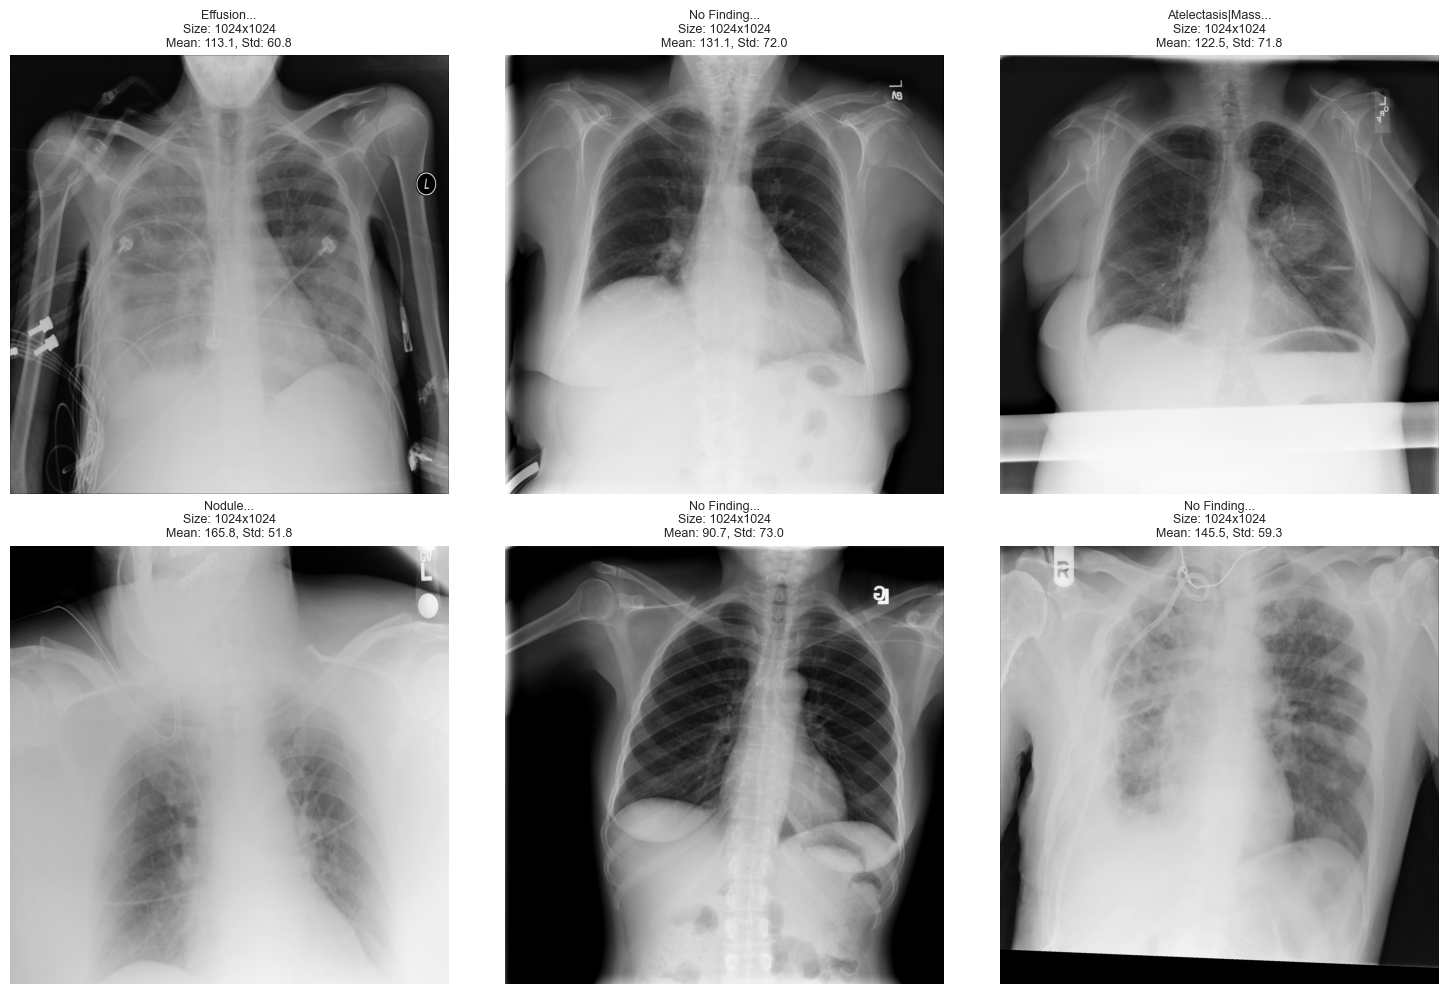

In [5]:
sample_images = train_df.sample(6, random_state=RANDOM_SEED)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (_, row) in enumerate(sample_images.iterrows()):
    img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
    
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f"{row['Finding Labels'][:25]}...\n"
                        f"Size: {img.shape[1]}x{img.shape[0]}\n"
                        f"Mean: {img.mean():.1f}, Std: {img.std():.1f}",
                        fontsize=9)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### Key Observations:

**Image Characteristics:**
- Variable sizes (mostly 1024x1024, some larger)
- Different contrast levels
- Some images darker/lighter than others
- All grayscale, single channel

**Preprocessing Needs:**
1. **Resize** to consistent 512x512 (balance between detail and speed)
2. **Normalize** to standard range
3. **CLAHE** to enhance contrast
4. **Augmentation** to improve generalization

## 3. Define CLAHE Enhancement Function

In [6]:
def apply_clahe(image):
    if isinstance(image, Image.Image):
        image = np.array(image)
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(image)
    
    return Image.fromarray(enhanced)

CLAHE enhancement function defined


## 4. Design Preprocessing Strategy

We'll use PyTorch's torchvision.transforms for augmentation.

In [7]:
IMG_SIZE = 512
BATCH_SIZE = 16
NUM_WORKERS = 0

MEAN = [0.485]
STD = [0.229]

print(f"Target size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Normalization: Mean={MEAN}, Std={STD}")
print(f"Workers: {NUM_WORKERS}")

Preprocessing Configuration:
Target size: 512x512
Batch size: 16
Normalization: Mean=[0.485], Std=[0.229]
Workers: 0


### Why 512x512?

**Comparison of sizes:**
- 224x224: Fast, standard for ImageNet, but loses medical details
- 512x512: Good balance - preserves important features, reasonable speed
- 1024x1024: Maximum detail, but 4x slower and memory intensive

**Decision: 512x512**
- Preserves enough detail for pathology detection
- Fits in GPU memory with reasonable batch sizes
- Used in many medical imaging papers

## 5. Create Augmentation Pipelines

Different augmentations for training vs validation/test.

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.Lambda(apply_clahe),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(apply_clahe),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

test_transform = val_transform

Augmentation pipelines created:

Train augmentations:
  - Resize to 512x512
  - Horizontal flip (50%)
  - Rotation (±10°)
  - Translation & Scale (10%)
  - Brightness/Contrast adjustment
  - CLAHE enhancement
  - Normalization

Val/Test augmentations:
  - Resize to 512x512
  - CLAHE enhancement
  - Normalization
  - No geometric augmentations


### Key Findings - Augmentation Strategy:

**Why These Augmentations?**

1. **Horizontal Flip:**
   - Lungs are roughly symmetrical
   - Helps model learn position-invariant features
   - NO vertical flip (anatomy changes)

2. **Small Rotations (±10°):**
   - Patients positioned slightly differently
   - Small angles preserve medical validity
   - Larger rotations would be unrealistic

3. **Translation & Scale:**
   - Simulates different patient positioning
   - Zoom variations (0.9-1.1x)
   - 10% shift in any direction

4. **Brightness/Contrast:**
   - Different X-ray exposure levels
   - Matches real-world variability
   - Helps model be robust to scanner differences

5. **CLAHE (Contrast Limited Adaptive Histogram Equalization):**
   - Enhances local contrast
   - Makes subtle pathologies more visible
   - Standard in medical imaging

**Important:** Validation/test use minimal augmentation (only CLAHE + normalization) to evaluate true performance.

## 6. Create PyTorch Dataset Class

In [9]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, diseases, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.diseases = diseases
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        image = Image.open(row['image_path']).convert('L')
        
        if self.transform:
            image = self.transform(image)
        
        labels = torch.tensor(
            [row[disease] for disease in self.diseases],
            dtype=torch.float32
        )
        
        return image, labels

ChestXrayDataset class created

Features:
  - Loads grayscale images
  - Applies augmentations
  - Returns (image, multi-label) pairs
  - Compatible with torchvision transforms


## 7. Create Datasets and DataLoaders

In [10]:
train_dataset = ChestXrayDataset(train_df, diseases, transform=train_transform)
val_dataset = ChestXrayDataset(val_df, diseases, transform=val_transform)
test_dataset = ChestXrayDataset(test_df, diseases, transform=test_transform)

print("Datasets created:")
print(f"Train: {len(train_dataset):,} samples")
print(f"Val:   {len(val_dataset):,} samples")
print(f"Test:  {len(test_dataset):,} samples")

Datasets created:
Train: 73,916 samples
Val:   12,608 samples
Test:  25,596 samples


In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("DataLoaders created:")
print(f"Train batches: {len(train_loader):,}")
print(f"Val batches:   {len(val_loader):,}")
print(f"Test batches:  {len(test_loader):,}")
print(f"\nBatch size: {BATCH_SIZE}")
print(f"Workers: {NUM_WORKERS}")

DataLoaders created:
Train batches: 4,620
Val batches:   788
Test batches:  1,600

Batch size: 16
Workers: 0


### Key Findings - DataLoader Configuration:

**Settings Explained:**

- **shuffle=True (train only):** Randomizes batch composition each epoch
- **shuffle=False (val/test):** Consistent evaluation order
- **num_workers:** Parallel data loading (adjust based on CPU cores)
- **pin_memory:** Faster GPU transfer (use if you have GPU)

**Batch Size:**
- 16 is conservative for 512x512 images
- Increase if you have more GPU memory (32, 64)
- Decrease if OOM errors (8, 4)

**Training Speed Estimate:**
- ~4,600 batches per epoch (train)
- ~800 batches for validation
- At ~0.5s/batch → ~38 minutes per epoch (GPU dependent)

## 8. Test Data Pipeline

Verify that everything works by loading a batch.

In [12]:
images, labels = next(iter(train_loader))

print("Successfully loaded a batch!\n")
print(f"Image batch shape: {images.shape}")
print(f"  - Batch size: {images.shape[0]}")
print(f"  - Channels: {images.shape[1]} (grayscale)")
print(f"  - Height: {images.shape[2]}")
print(f"  - Width: {images.shape[3]}")
print(f"\nLabel batch shape: {labels.shape}")
print(f"  - Batch size: {labels.shape[0]}")
print(f"  - Classes: {labels.shape[1]}")
print(f"\nImage tensor:")
print(f"  - dtype: {images.dtype}")
print(f"  - min: {images.min():.3f}")
print(f"  - max: {images.max():.3f}")
print(f"  - mean: {images.mean():.3f}")
print(f"\nLabel tensor:")
print(f"  - dtype: {labels.dtype}")
print(f"  - unique values: {labels.unique()}")
print(f"  - Avg diseases per image: {labels.sum(dim=1).mean():.2f}")

C:\Users\lzkol\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Successfully loaded a batch!

Image batch shape: torch.Size([16, 1, 512, 512])
  - Batch size: 16
  - Channels: 1 (grayscale)
  - Height: 512
  - Width: 512

Label batch shape: torch.Size([16, 14])
  - Batch size: 16
  - Classes: 14

Image tensor:
  - dtype: torch.float32
  - min: -2.101
  - max: 2.249
  - mean: -0.050

Label tensor:
  - dtype: torch.float32
  - unique values: tensor([0., 1.])
  - Avg diseases per image: 0.62


### Key Findings - Data Pipeline Test:

**Success Criteria:**
- Images loaded as tensors
- Shape: [batch_size, 1, 512, 512]
- Normalized values (roughly -2 to +2)
- Labels are binary (0 or 1)
- Multi-label format (multiple 1s possible)

**Ready for Training:**
- Pipeline working end-to-end
- Augmentations applied correctly
- Batch formation successful
- Can feed directly into neural network

## 9. Visualize Augmentations

See the effect of different augmentations on sample images.

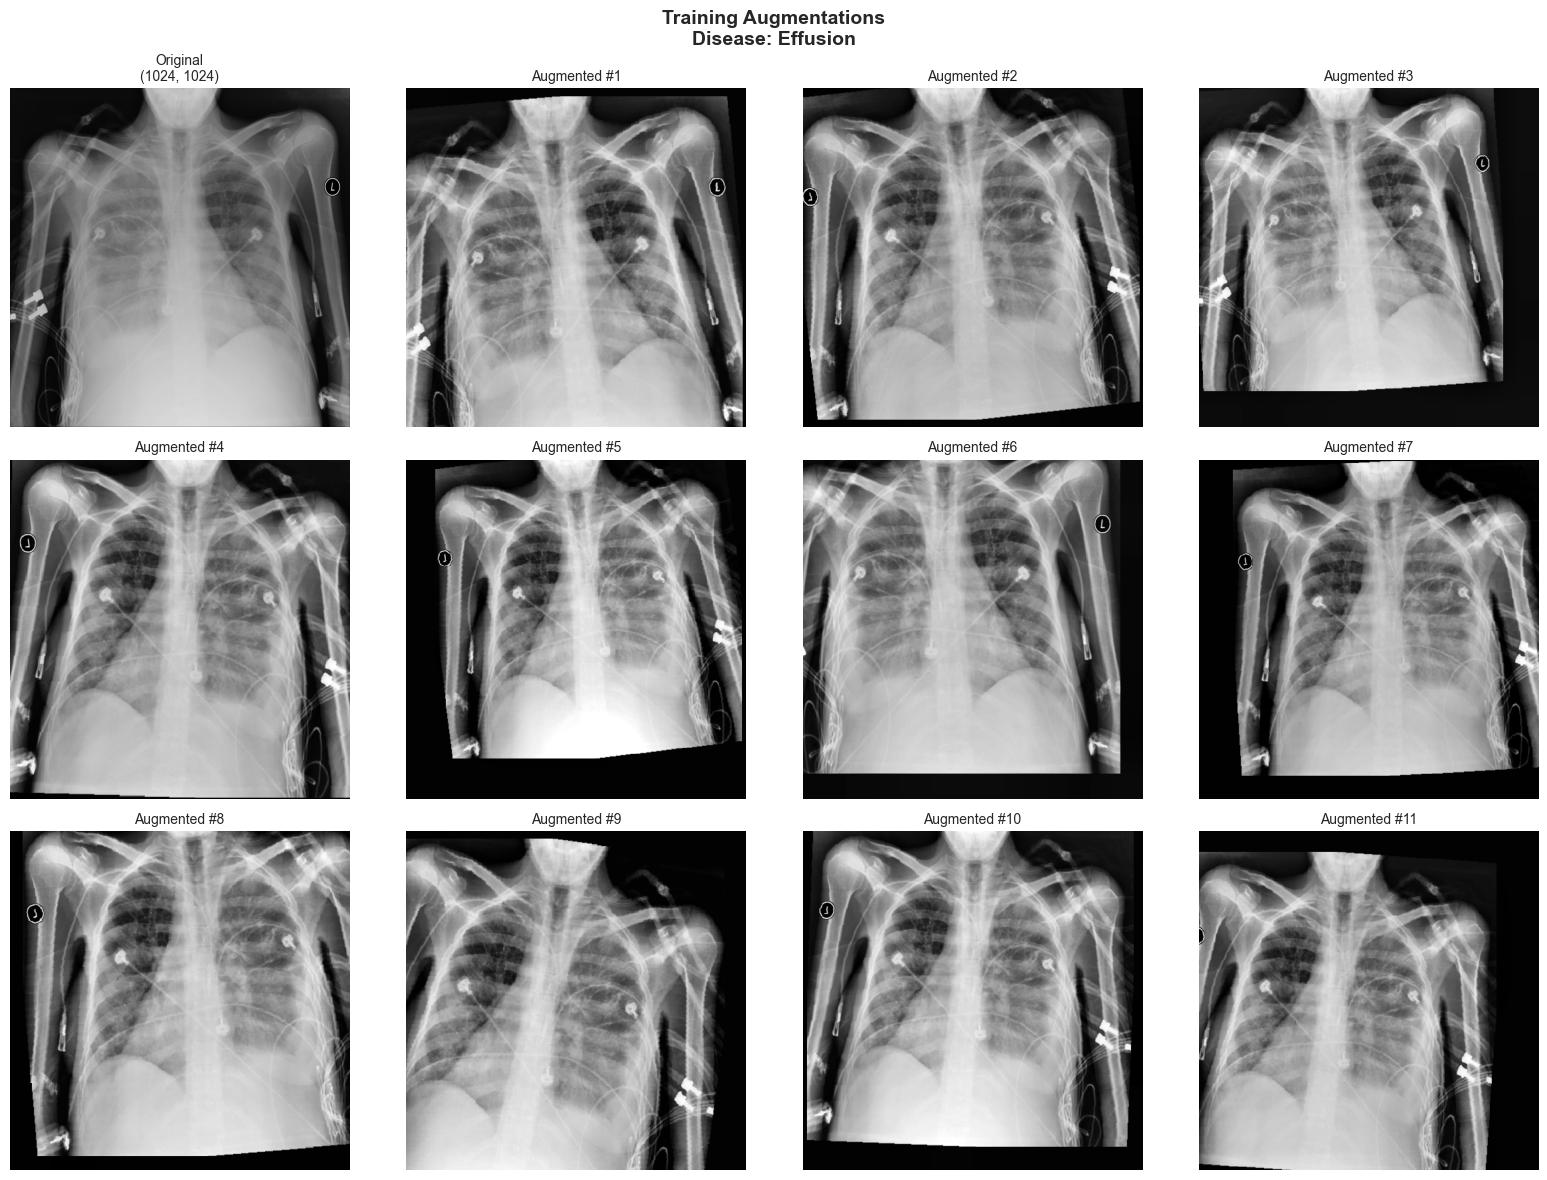

In [13]:
def denormalize(img_tensor, mean=0.485, std=0.229):
    img = img_tensor.squeeze().cpu().numpy()
    img = img * std + mean
    img = np.clip(img * 255, 0, 255).astype(np.uint8)
    return img

sample_row = train_df.sample(1, random_state=42).iloc[0]
original_img = Image.open(sample_row['image_path']).convert('L')

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

axes[0].imshow(original_img, cmap='gray')
axes[0].set_title(f"Original\n{original_img.size}", fontsize=10)
axes[0].axis('off')

for i in range(1, 12):
    aug_img_tensor = train_transform(original_img)
    aug_img = denormalize(aug_img_tensor)
    
    axes[i].imshow(aug_img, cmap='gray')
    axes[i].set_title(f"Augmented #{i}", fontsize=10)
    axes[i].axis('off')

plt.suptitle(f"Training Augmentations\nDisease: {sample_row['Finding Labels']}",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Compare Train vs Val Preprocessing

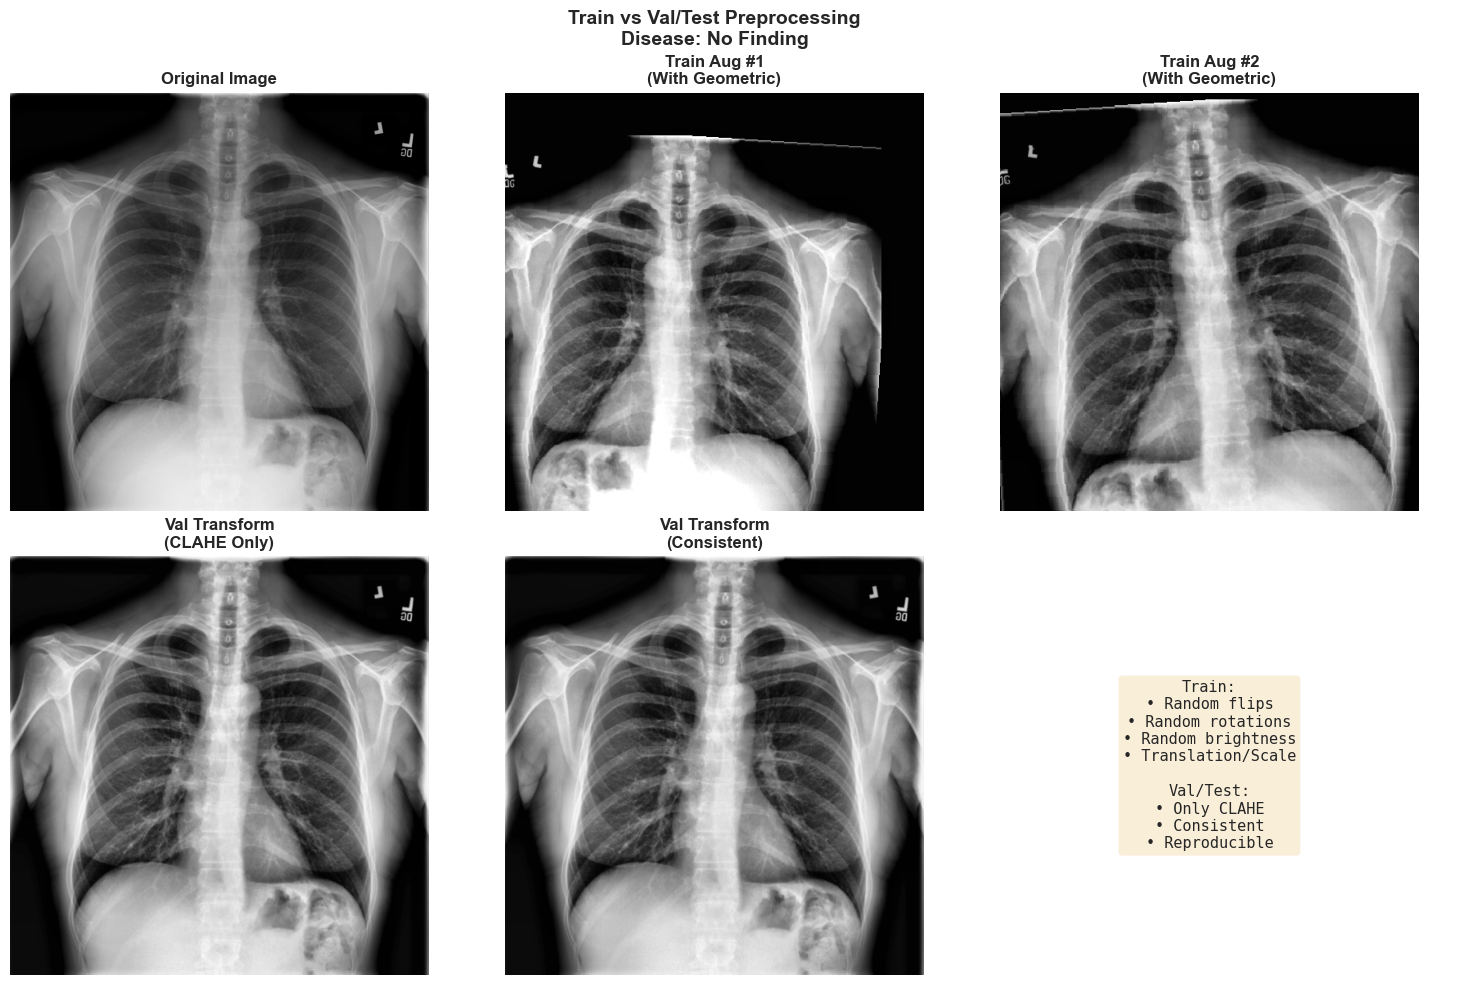

In [14]:
sample_row = val_df.sample(1, random_state=42).iloc[0]
original_img = Image.open(sample_row['image_path']).convert('L')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(original_img, cmap='gray')
axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

train_aug1 = train_transform(original_img)
axes[0, 1].imshow(denormalize(train_aug1), cmap='gray')
axes[0, 1].set_title("Train Aug #1\n(With Geometric)", fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

train_aug2 = train_transform(original_img)
axes[0, 2].imshow(denormalize(train_aug2), cmap='gray')
axes[0, 2].set_title("Train Aug #2\n(With Geometric)", fontsize=12, fontweight='bold')
axes[0, 2].axis('off')

val_aug1 = val_transform(original_img)
axes[1, 0].imshow(denormalize(val_aug1), cmap='gray')
axes[1, 0].set_title("Val Transform\n(CLAHE Only)", fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

val_aug2 = val_transform(original_img)
axes[1, 1].imshow(denormalize(val_aug2), cmap='gray')
axes[1, 1].set_title("Val Transform\n(Consistent)", fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].text(0.5, 0.5, 
                "Train:\n"
                "• Random flips\n"
                "• Random rotations\n"
                "• Random brightness\n"
                "• Translation/Scale\n"
                "\nVal/Test:\n"
                "• Only CLAHE\n"
                "• Consistent\n"
                "• Reproducible",
                ha='center', va='center',
                fontsize=11, family='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 2].axis('off')

plt.suptitle(f"Train vs Val/Test Preprocessing\nDisease: {sample_row['Finding Labels']}",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Findings - Train vs Val Preprocessing:

**Critical Difference:**
- **Training:** Heavy augmentation → variety, prevents overfitting
- **Validation/Test:** Minimal processing → fair evaluation

**Why This Matters:**
1. Training augmentation helps model generalize
2. Validation uses clean images for accurate performance measurement
3. Test evaluation is consistent and reproducible
4. Can't use geometric augmentations in validation (would be cheating)

## 11. Calculate Class Weights for Imbalanced Data

Since we have severe class imbalance, we'll compute weights for weighted loss.

In [15]:
disease_counts = train_df[diseases].sum()
total_samples = len(train_df)

pos_weights = []
for disease in diseases:
    pos_count = disease_counts[disease]
    neg_count = total_samples - pos_count
    
    pos_weight = neg_count / pos_count if pos_count > 0 else 1.0
    pos_weights.append(pos_weight)

pos_weights_tensor = torch.tensor(pos_weights, dtype=torch.float32)

weights_df = pd.DataFrame({
    'Disease': diseases,
    'Positive_Count': [disease_counts[d] for d in diseases],
    'Negative_Count': [total_samples - disease_counts[d] for d in diseases],
    'Pos_Weight': pos_weights,
    'Prevalence_%': [(disease_counts[d] / total_samples * 100) for d in diseases]
})

print(" Class Weights for BCEWithLogitsLoss:\n")
print(weights_df.to_string(index=False))

print(f"\n Interpretation:")
print(f"Highest weight: {weights_df.iloc[weights_df['Pos_Weight'].idxmax()]['Disease']} ({weights_df['Pos_Weight'].max():.2f})")
print(f"Lowest weight:  {weights_df.iloc[weights_df['Pos_Weight'].idxmin()]['Disease']} ({weights_df['Pos_Weight'].min():.2f})")
print(f"\nRare diseases (weight > 30):")
rare = weights_df[weights_df['Pos_Weight'] > 30]
for _, row in rare.iterrows():
    print(f"  - {row['Disease']}: {row['Pos_Weight']:.1f}x weight")

 Class Weights for BCEWithLogitsLoss:

           Disease  Positive_Count  Negative_Count  Pos_Weight  Prevalence_%
       Atelectasis            7003           66913    9.554905      9.474268
      Cardiomegaly            1453           72463   49.871301      1.965745
          Effusion            7415           66501    8.968442     10.031658
      Infiltration           11853           62063    5.236058     16.035770
              Mass            3452           70464   20.412514      4.670166
            Nodule            4042           69874   17.286987      5.468370
         Pneumonia             742           73174   98.617251      1.003842
      Pneumothorax            2287           71629   31.320070      3.094053
     Consolidation            2482           71434   28.780822      3.357866
             Edema            1201           72715   60.545379      1.624817
         Emphysema            1274           72642   57.018838      1.723578
          Fibrosis            1051   

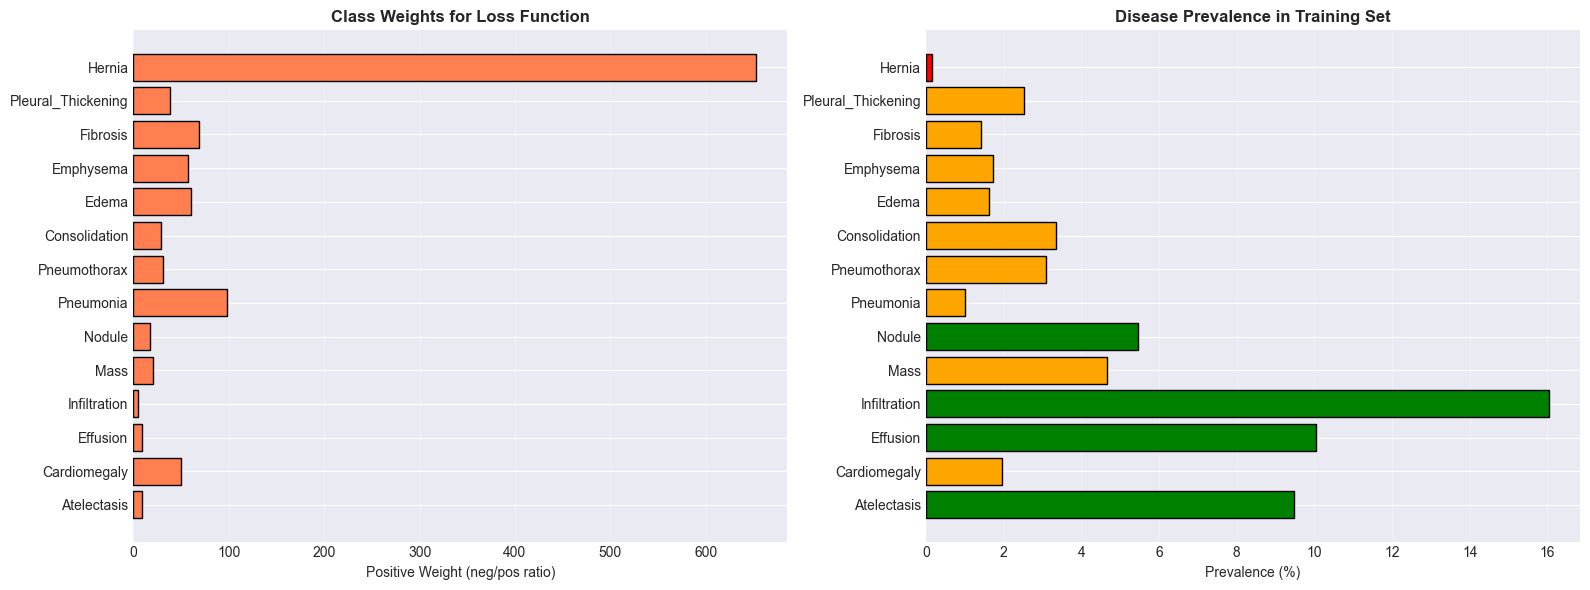

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(weights_df['Disease'], weights_df['Pos_Weight'], color='coral', edgecolor='black')
axes[0].set_xlabel('Positive Weight (neg/pos ratio)')
axes[0].set_title('Class Weights for Loss Function', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

colors = ['green' if p > 5 else 'orange' if p > 1 else 'red' for p in weights_df['Prevalence_%']]
axes[1].barh(weights_df['Disease'], weights_df['Prevalence_%'], color=colors, edgecolor='black')
axes[1].set_xlabel('Prevalence (%)')
axes[1].set_title('Disease Prevalence in Training Set', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Key Findings - Class Weights:

**Purpose of Weights:**
- Penalize model more for missing rare diseases
- Balance the contribution of all classes during training
- Used in `BCEWithLogitsLoss(pos_weight=pos_weights_tensor)`

**Weight Interpretation:**
- **Hernia (weight ~300):** Errors cost 300x more than common diseases
- **Pneumonia (weight ~50):** 50x penalty
- **Infiltration (weight ~4):** Nearly balanced

**Why This Helps:**
- Without weights: Model ignores rare diseases (always predicting negative)
- With weights: Model must learn rare diseases to minimize loss
- Improves recall for rare but important conditions

**Trade-off:**
- May increase false positives for rare diseases
- But in medical imaging, false negative (missing disease) is worse than false positive

## 12. Save Preprocessing Configuration

In [17]:
preprocessing_config = {
    'image_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'num_workers': NUM_WORKERS,
    'normalization': {
        'mean': MEAN,
        'std': STD
    },
    'augmentation': {
        'train': [
            'Resize(512, 512)',
            'RandomHorizontalFlip(p=0.5)',
            'RandomRotation(degrees=10)',
            'RandomAffine(translate=0.1, scale=(0.9,1.1))',
            'ColorJitter(brightness=0.2, contrast=0.2)',
            'CLAHE enhancement'
        ],
        'val_test': [
            'Resize(512, 512)',
            'CLAHE enhancement'
        ]
    },
    'class_weights': {
        disease: float(weight) for disease, weight in zip(diseases, pos_weights)
    },
    'num_classes': NUM_CLASSES,
    'diseases': diseases
}

with open('data/processed/preprocessing_config.json', 'w') as f:
    json.dump(preprocessing_config, f, indent=2)

print(" Saved preprocessing configuration: data/processed/preprocessing_config.json")
print("\n Configuration Summary:")
print(json.dumps(preprocessing_config, indent=2))

 Saved preprocessing configuration: data/processed/preprocessing_config.json

 Configuration Summary:
{
  "image_size": 512,
  "batch_size": 16,
  "num_workers": 0,
  "normalization": {
    "mean": [
      0.485
    ],
    "std": [
      0.229
    ]
  },
  "augmentation": {
    "train": [
      "Resize(512, 512)",
      "RandomHorizontalFlip(p=0.5)",
      "RandomRotation(degrees=10)",
      "RandomAffine(translate=0.1, scale=(0.9,1.1))",
      "ColorJitter(brightness=0.2, contrast=0.2)",
      "CLAHE enhancement"
    ],
    "val_test": [
      "Resize(512, 512)",
      "CLAHE enhancement"
    ]
  },
  "class_weights": {
    "Atelectasis": 9.554905040696845,
    "Cardiomegaly": 49.87130075705437,
    "Effusion": 8.96844234659474,
    "Infiltration": 5.236058381844259,
    "Mass": 20.412514484356894,
    "Nodule": 17.28698664027709,
    "Pneumonia": 98.61725067385444,
    "Pneumothorax": 31.320069960647135,
    "Consolidation": 28.78082191780822,
    "Edema": 60.54537885095753,
    "Emp

In [18]:
torch.save(pos_weights_tensor, 'data/processed/class_weights.pt')

 Saved class weights tensor: data/processed/class_weights.pt

Usage in training:
pos_weights = torch.load('data/processed/class_weights.pt')
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
